This notebook is very similar to FPCA_preprocessing, but it's built to show the behavior of different cutoffs that were considered (522 and 722), as well as what would happen if we didn't use a lowpass filter at all.

In [536]:
import pandas as pd
from scipy.io import wavfile
from egg_io import *
from fpca_preprocess import *
import matplotlib.pyplot as plt

all_data = pd.read_csv("voiceSauce.csv")
TIMEPOINT = 5
savedRow = grabSpecificFile(all_data, 'egg_melt/Gujarati/2009-07-24-1800-40_ch1.wav')

In [537]:
# Example for 722 vs 922:
# savedRow = grabSpecificFile(all_data, 'egg_melt/Hmong/14e-pam_2_-w.pmf')

In [538]:
egg, samplerate = loadFile(savedRow, TIMEPOINT)

/Users/henryheyden/Documents/hp/voice_quality_honorsthesis/preprocessing/egg_io.py:23: WavFileWarning: Reached EOF prematurely; finished at 440364 bytes, expected 880648 bytes from header.
  samplerate, data = wavfile.read(filepath_string)


In [539]:
egg_522 = lowpass(egg, samplerate, 522)
egg_722 = lowpass(egg, samplerate, 722)
egg_922 = lowpass(egg, samplerate, 922)

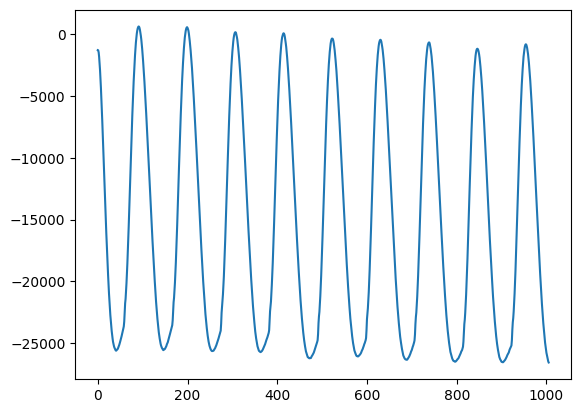

In [540]:
plt.plot(egg_922)

In [541]:
signals_for_plotting = []
for egg_signal in [egg, egg_722, egg_922]:
    peaks = pitchmark(egg_signal, samplerate, savedRow.strF0)
    threshold = find_threshold(egg_signal, peaks)
    clipped_egg = clip_egg(egg_signal, threshold, peaks)
    signals_for_plotting.append(normalize_egg(clipped_egg))

<function matplotlib.pyplot.show(close=None, block=None)>

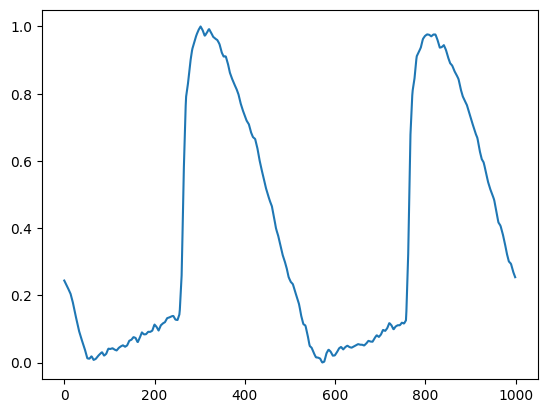

In [542]:
# This is without a lowpass filter:

plt.plot(signals_for_plotting[0])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

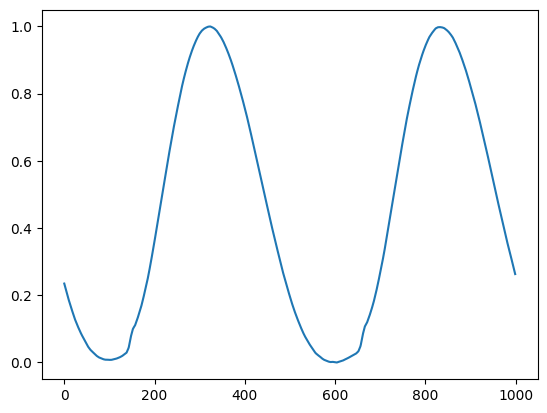

In [543]:
# This is with a cutoff of 522 Hz:

plt.plot(signals_for_plotting[1])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

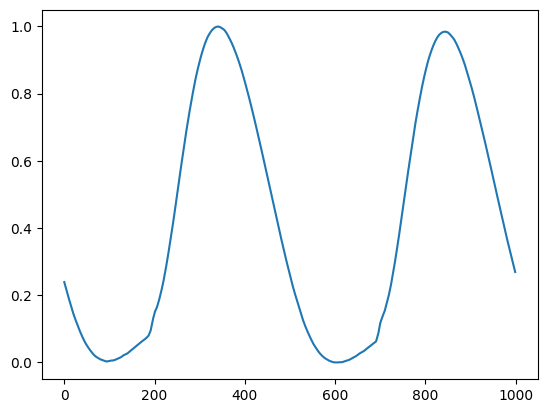

In [544]:
# This is with a cutoff of 722 Hz:

plt.plot(signals_for_plotting[2])
plt.show